In [ ]:
!hostname

gpua087.delta.ncsa.illinois.edu


In [2]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt
import seaborn as sns

/projects/bhdw/asachan/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/projects/bhdw/asachan/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/projects/bhdw/asachan/.conda/envs/decoupler_psc/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [3]:
import os
os.chdir('/projects/bgdb/asachan/methods/maxToki-multimodal/sub-packages/bionemo-maxtoki/src/bionemo/maxtoki')  # directory containing utils.py
import sys
import logging
import warnings

export_dir = "/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human"
raw_dir = "/work/hdd/bgdb/asachan/datasets_hdd/SKM_multimodal_ageing/raw_files"
multiVI_dir = "/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/multiVI_outs"
out_tmp = '/projects/bgdb/asachan/tmp'

In [4]:
pd.set_option('mode.string_storage', 'python')

In [6]:
# from utils import *

In [7]:
atac_data_file = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/atac_objects/atac_fiber/atac_female_type2.h5ad'
rna_data_file = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad'

In [ ]:
rna = sc.read_h5ad(rna_data_file)

In [9]:
rna

AnnData object with n_obs × n_vars = 4111 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'score_aucell'
    varm: 'PCs'
    layers: 'counts', 'counts_float', 'lognorm'
    obsp: 'connectivities', 'distances'

In [ ]:
rna.obs['sample'].value_counts()

sample
YM2    1989
OM9    1278
OM6     722
P26     122
Name: count, dtype: int64

In [15]:
rna.obs['age'].value_counts()

age
80    2000
34    1989
17     122
Name: count, dtype: int64

### makes sense to remove the 17 y/o cells 

In [18]:
rna = rna[rna.obs['age'] != 17].copy()
rna.obs['age'].value_counts()


age
80    2000
34    1989
Name: count, dtype: int64

In [19]:
# over-write 
rna.write_h5ad('/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad')

In [21]:
atac = sc.read_h5ad(atac_data_file)

In [22]:
atac

AnnData object with n_obs × n_vars = 7831 × 265003
    obs: 'replicates', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'orig.ident', 'sample', 'group', 'ReadsInPeaks', 'FRIP', 'fiber_class_1_anno', 'Annotation', 'UMAP_1', 'UMAP_2', 'fiber_class_anno', 'country', 'age', 'Sex'
    obsm: 'X_UMAP'
    layers: 'Tn5_insertion_counts'

In [23]:
atac.obs['sample'].value_counts()

sample
YM2    3349
OM9    2238
P26    2001
OM6     243
Name: count, dtype: int64

In [24]:
atac.obs['age'].value_counts()

age
34    3349
80    2238
17    2001
90     243
Name: count, dtype: int64

In [25]:
atac = atac[atac.obs['sample'].isin(['YM2', 'OM9', 'OM6'])].copy()

In [26]:
# rebael all OM6 sample cells as 80 in the age column
atac.obs.loc[atac.obs['sample'] == 'OM6', 'age'] = 80
atac.obs['age'].value_counts()


age
34    3349
80    2481
Name: count, dtype: int64

In [27]:
# over-write
atac.write_h5ad('/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/atac_objects/atac_fiber/atac_female_type2.h5ad')

## Old code

In [6]:
import mudata as md

mdata = md.read_h5mu(f'{multiVI_dir}/multivi_trained.h5mu')
rna_adata = sc.read_h5ad('/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_counts_added.h5ad')

/projects/bgdb/asachan/.conda/envs/multivi/lib/python3.11/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/projects/bgdb/asachan/.conda/envs/multivi/lib/python3.11/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [7]:
rna_adata

AnnData object with n_obs × n_vars = 13186 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count'
    var: 'features'
    uns: 'rank_genes_groups'
    obsm: 'X_umap'
    layers: 'counts', 'counts_float', 'lognorm'

/projects/bgdb/asachan/methods/maxToki-multimodal/sub-packages/bionemo-maxtoki/src/bionemo/maxtoki/utils.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin = sns.violinplot(


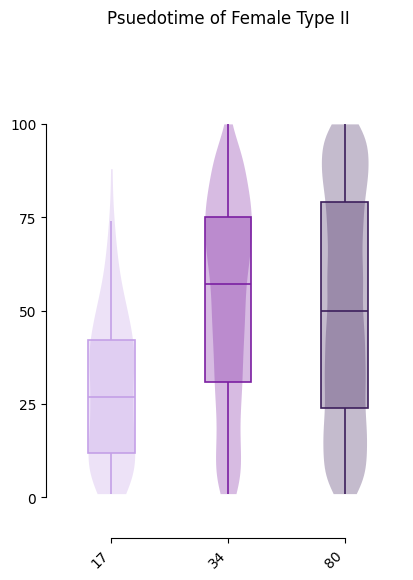

<Figure size 640x480 with 0 Axes>

In [ ]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = rna_adata.obs[['sample', 'age', 'Pseudotime_typeII']].copy()
plot_data = cell_level_scores_df.copy()
plot_data['age'] = plot_data['age'].astype(str)

custom_colors = {
    '17': '#C4A0E7',
    '34': '#7B1FA2',
    '80': '#3D1F5C'
}

# custom_colors = {
#     '38': '#87CEEB',  # Sky blue
#     '45': '#4682B4',  # Steel blue
#     '82': '#191970'  # Midnight blue,
# }

fig = plot_violin_box_combo(
    data=plot_data,
    x_var='age',
    y_var='Pseudotime_typeII',
    title='Psuedotime of Female Type II',
    x_ticks=['17','34','80'],
    palette=custom_colors,
    rotation=45,
    show_scatter=False
)

# Display the plot
from IPython.display import display
display(fig)
# save as pdf 
#fig.savefig('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/figures/cellage_scores.pdf', bbox_inches='tight')

In [11]:
rna_adata.obs['age'].value_counts()

age
80    11075
34     1989
17      122
Name: count, dtype: int64

In [ ]:
def downsample_wrt_obs_value(
    adata: AnnData,
    age_to_downsample,
    n_keep: int,
    obs_col: str = 'Pseudotime_typeII',
    age_col: str = 'age',
) -> AnnData:
    """
    Within `age_to_downsample`, keep only the n_keep cells with highest pseudotime.
    All other age groups pass through unchanged. NaN pseudotimes in the target
    group are dropped (nlargest skips them); NaNs elsewhere are preserved.
    """
    obs = adata.obs
    target_mask = (obs[age_col] == age_to_downsample).values
    n_target = target_mask.sum()

    if n_target <= n_keep:
        print(f"Age {age_to_downsample}: {n_target} ≤ n_keep ({n_keep}); returning unchanged.")
        return adata.copy()

    # Top n_keep cells *within* the target group, ranked by pseudotime
    top_idx = obs.loc[target_mask, obs_col].nlargest(n_keep).index

    # Mask: keep if (not in target group) OR (in target group AND in top-n)
    keep_mask = ~target_mask | obs.index.isin(top_idx)
    out = adata[keep_mask].copy()

    threshold = obs.loc[top_idx, obs_col].min()
    print(f"Age {age_to_downsample}: kept {n_keep}/{n_target} cells "
          f"(pseudotime ≥ {threshold:.3f}, ~{n_keep/n_target*100:.0f}th-percentile cut from below)")
    return out

In [ ]:
rna_adata_ds = downsample_wrt_obs_value(
    rna_adata,
    age_to_downsample=80,
    n_keep=6000,
    obs_col='Pseudotime_typeII',
)

Age 80: kept 6000/11075 cells (pseudotime ≥ 33.000, ~54th-percentile cut from below)


/projects/bgdb/asachan/methods/maxToki-multimodal/sub-packages/bionemo-maxtoki/src/bionemo/maxtoki/utils.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin = sns.violinplot(


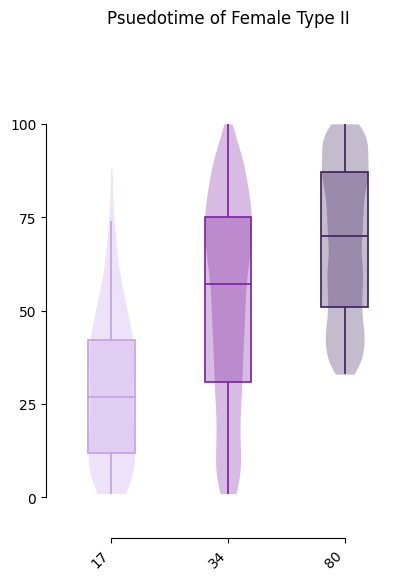

<Figure size 640x480 with 0 Axes>

In [16]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = rna_adata_ds.obs[['sample', 'age', 'Pseudotime_typeII']].copy()
plot_data = cell_level_scores_df.copy()
plot_data['age'] = plot_data['age'].astype(str)

custom_colors = {
    '17': '#C4A0E7',
    '34': '#7B1FA2',
    '80': '#3D1F5C'
}

# custom_colors = {
#     '38': '#87CEEB',  # Sky blue
#     '45': '#4682B4',  # Steel blue
#     '82': '#191970'  # Midnight blue,
# }

fig = plot_violin_box_combo(
    data=plot_data,
    x_var='age',
    y_var='Pseudotime_typeII',
    title='Psuedotime of Female Type II',
    x_ticks=['17','34','80'],
    palette=custom_colors,
    rotation=45,
    show_scatter=False
)

# Display the plot
from IPython.display import display
display(fig)
# save as pdf 
#fig.savefig('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/figures/cellage_scores.pdf', bbox_inches='tight')

In [17]:
rna_adata_ds

AnnData object with n_obs × n_vars = 8111 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count'
    var: 'features'
    uns: 'rank_genes_groups'
    obsm: 'X_umap'
    layers: 'counts', 'counts_float', 'lognorm'

In [18]:
# 0. Make sure .X holds normalized data (most scanpy functions read from .X)
rna_adata_ds.X = rna_adata_ds.layers['lognorm'].copy()

# 1. HVGs on the lognorm layer (variance is what matters; flavor='seurat' for log-normalized)
sc.pp.highly_variable_genes(rna_adata_ds, n_top_genes=4000, flavor='seurat')

# 2. PCA on HVGs only
sc.pp.pca(rna_adata_ds, n_comps=50, use_highly_variable=True)

# 3. kNN graph from PCA — this is what populates obsp['connectivities'/'distances']
sc.pp.neighbors(rna_adata_ds, use_rep='X_pca', n_neighbors=15, random_state=0)

/projects/bgdb/asachan/.conda/envs/multivi/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/projects/bgdb/asachan/.conda/envs/multivi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


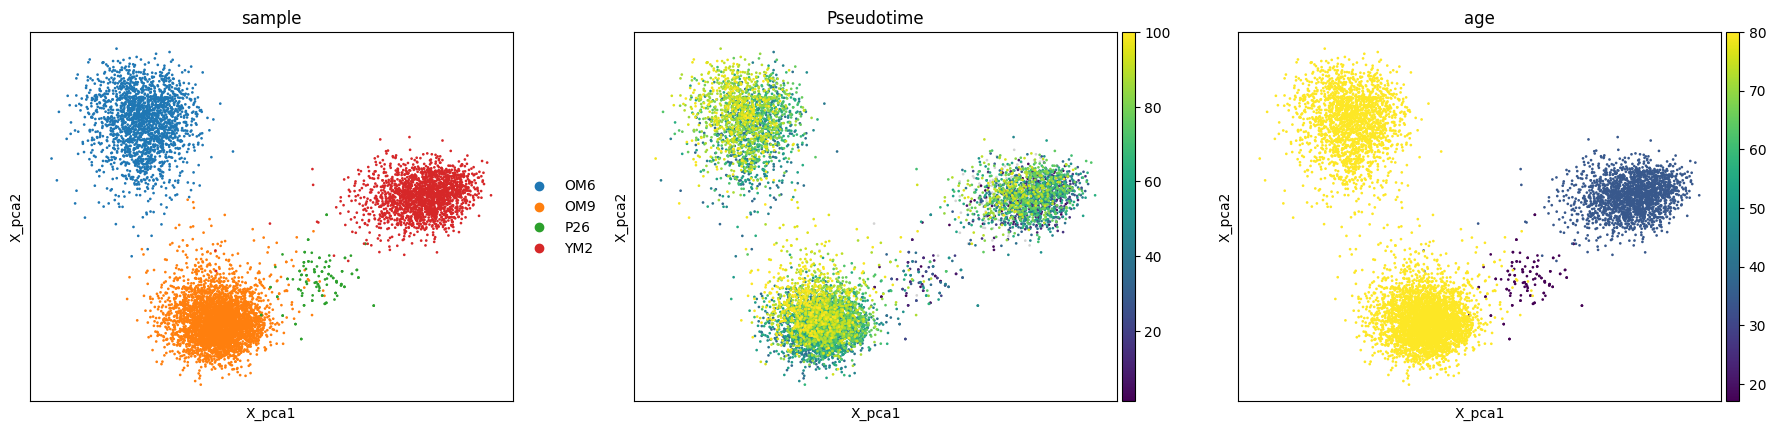

In [20]:
sc.pl.embedding(rna_adata_ds, basis='X_pca', color=['sample', 'Pseudotime', 'age'])

In [23]:
#write to file
rna_adata_ds.write_h5ad('/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_ds_wrt_time.h5ad')